# 10주차_머신러닝 분석 방법론 Ⅰ

- 로지스틱 회귀분석 (분류 모델)

---

In [7]:
# 필요한 패키지 설치

import pandas as pd 
# pandas 라이브러리를 불러옴 → 표 형태의 데이터를 다루는 데이터프레임 구조를 제공함
# 데이터 불러오기, 결측값 처리, 열 추출, 그룹화, 요약 통계 계산 등의 작업을 효율적으로 처리할 수 있는 도구를 제공함

import numpy as np
# numpy 라이브러리를 불러옴 → 다차원 배열(n-dimensional array) 및 수치 연산 기능을 제공함
# 선형대수 연산, 난수 생성, 벡터화된 연산 등을 가능하게 하며 데이터 처리의 기반 수학 연산 도구로 사용됨

from sklearn.preprocessing import RobustScaler
# sklearn의 전처리 모듈에서 RobustScaler 클래스를 불러옴
# 중앙값(median)과 IQR(사분위 범위)을 기준으로 데이터를 스케일링하여 이상치(outlier)의 영향을 줄이는 정규화 기법을 제공함

from sklearn.linear_model import LogisticRegression
# sklearn의 선형 모델 모듈에서 로지스틱 회귀(Logistic Regression) 모델을 불러옴
# 이진 분류(binary classification) 문제에서 클래스 확률을 예측하고, 시그모이드 함수를 기반으로 클래스 0 또는 1을 예측하는 분류 알고리즘을 제공함

from sklearn.model_selection import train_test_split
# sklearn의 model_selection 모듈에서 학습용/테스트용 데이터를 나누기 위한 train_test_split 함수를 불러옴
# 전체 데이터를 모델 학습용 데이터와 성능 평가용 데이터로 무작위로 분할하는 기능을 제공함

from imblearn.under_sampling import *
# imbalanced-learn 라이브러리에서 언더샘플링 기법 전부를 불러옴
# 클래스 불균형 문제를 해결하기 위해 다수 클래스의 샘플 수를 줄여서 소수 클래스와 균형을 맞추는 다양한 기법(예: RandomUnderSampler 등)을 제공함

import statsmodels.api as sm
# 통계 분석 라이브러리인 statsmodels의 API를 불러옴
# OLS 회귀분석, 로지스틱 회귀, 시계열 분석 등 다양한 고급 통계 모델과 유의성 검정, 회귀 요약 테이블 등을 제공함

import seaborn as sns
# seaborn 시각화 라이브러리를 불러옴 → 통계 시각화를 위한 고수준 인터페이스 제공함
# 히트맵, 상관관계 플롯, 분포 시각화 등 다양한 형태의 그래프를 쉽게 그릴 수 있도록 도와주는 도구임

import matplotlib.pyplot as plt
# matplotlib의 pyplot 모듈을 불러옴 → 기본적인 선형, 막대형, 산점도 그래프를 그릴 수 있는 시각화 도구 제공함
# seaborn과 함께 사용되어 시각적 분석, 결과 보고서 작성, 탐색적 분석 시 그림 출력을 담당함


In [8]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease
df = pd.read_csv("../../../main/datasets/heart_2020_cleaned.csv")

# 데이터 샘플 확인
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [3]:
# 컬럼 정보 확인

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [9]:
# 명목형 변수 더미처리

# 하나의 가변수 범주 제거 옵션 적용
df2 = pd.get_dummies(df, columns = ['HeartDisease','Smoking',
                                    'AlcoholDrinking','Stroke',
                                    'DiffWalking','Sex',
                                    'AgeCategory','Race',
                                    'Diabetic','PhysicalActivity',
                                    'GenHealth','Asthma',
                                    'KidneyDisease','SkinCancer']
                     ,drop_first=True
                    )
# 명목형(범주형) 변수들을 0과 1로 구성된 더미(dummy) 변수로 변환하여 새로운 데이터프레임 df2 생성함
# get_dummies 함수는 문자열 또는 범주형 데이터를 one-hot encoding 방식으로 처리하며, 각 범주를 개별 열로 확장함
# 예: 'Sex' 변수가 'Male', 'Female'이라면 → 'Sex_Male' 하나의 열로 변환됨 (drop_first=True 적용 시 Female은 기준값으로 제외됨)
# drop_first=True는 더미 변수 함정(dummy variable trap)을 방지하기 위한 옵션으로, 한 범주(기준) 값을 제거하여 다중공선성을 피함
# 이진 분류나 회귀 모델에서 불필요한 상관관계로 인해 수학적 문제가 발생하는 것을 방지하는 정규화 처리 방식임
# 처리된 결과는 모든 명목형 변수가 수치형 변수로 변환되어 머신러닝 모델에 바로 입력할 수 있는 구조로 정제됨

df2.head()


,BMI,PhysicalHealth,MentalHealth,SleepTime,HeartDisease_Yes,Smoking_Yes,AlcoholDrinking_Yes,Stroke_Yes,DiffWalking_Yes,Sex_Male,...,Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_Yes,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes
0,16.60,3.0,30.0,5.0,0,1,0,0,0,0,...,1,0,1,0,0,0,1,1,0,1
1,20.34,0.0,0.0,7.0,0,0,0,1,0,0,...,0,0,1,0,0,0,1,0,0,0
2,26.58,20.0,30.0,8.0,0,1,0,0,0,1,...,1,0,1,1,0,0,0,1,0,0
3,24.21,0.0,0.0,6.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,23.71,28.0,0.0,8.0,0,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,0


In [10]:
# RobustScaler 적용

# 숫자형 변수 분리
df_num = df[['BMI','PhysicalHealth','MentalHealth','SleepTime']]
# 원본 데이터프레임(df)에서 수치형 변수만 따로 추출하여 df_num에 저장함
# 각 변수는 연속형 데이터로서 스케일 조정이 필요한 특성임
# BMI(체질량지수), 신체 건강일수, 정신 건강일수, 수면 시간 변수는 분포가 왜곡되었을 가능성이 있으므로 정규화 대상이 됨

df_nom = df2.drop(['BMI','PhysicalHealth','MentalHealth','SleepTime'],axis=1)
# 더미화된 전체 테이블(df2)에서 위에서 선택한 수치형 변수들을 제거한 후 df_nom에 저장함
# 이로써 문자형 변수들이 더미 처리된 열만 분리된 상태로 유지됨
# 추후 스케일 조정된 수치형 데이터와 결합하기 위한 준비 작업임

# 숫자형 변수 RobustScaler 적용
RobustScaler = RobustScaler()
df_robust = RobustScaler.fit_transform(df_num)
# RobustScaler는 중앙값과 IQR(사분위 범위)을 기준으로 데이터를 스케일링함
# 이상치(outlier)의 영향을 줄이기 위해 평균과 표준편차 대신 중앙값과 IQR을 사용함
# fit_transform()은 스케일러를 학습(fit)하고, 데이터를 변환(transform)하는 과정을 동시에 수행함
# 결과는 numpy 배열 형태로 반환되며, 각 변수는 이상치의 영향을 받지 않는 상대적 척도로 변환됨

# 컬럼명 결합
df_num2 = pd.DataFrame(data=df_robust, columns=df_num.columns)
# 스케일링된 수치형 데이터를 다시 pandas 데이터프레임으로 변환하고 원래 컬럼명을 부여함
# 컬럼명이 유지되어야 이후 결합 시 변수 식별이 가능함

# 숫자형 테이블과 더미화 문자형 테이블 결합
df3 = pd.concat([df_num2, df_nom], axis=1)
# 스케일링된 수치형 데이터프레임(df_num2)과, 더미 처리된 명목형 데이터프레임(df_nom)을 수평 방향(axis=1)으로 결합함
# 모든 입력 변수가 수치형 형식으로 통합된 최종 모델 입력용 테이블(df3) 생성 완료됨
# 이 데이터는 머신러닝 모델 학습에 바로 사용할 수 있는 형태임

df3.head()


,BMI,PhysicalHealth,MentalHealth,SleepTime,HeartDisease_Yes,Smoking_Yes,AlcoholDrinking_Yes,Stroke_Yes,DiffWalking_Yes,Sex_Male,...,Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_Yes,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes
0,-1.453315,1.5,10.0,-1.0,0,1,0,0,0,0,...,1,0,1,0,0,0,1,1,0,1
1,-0.947226,0.0,0.0,0.0,0,0,0,1,0,0,...,0,0,1,0,0,0,1,0,0,0
2,-0.102842,10.0,10.0,0.5,0,1,0,0,0,1,...,1,0,1,1,0,0,0,1,0,0
3,-0.423545,0.0,0.0,-0.5,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,-0.491204,14.0,0.0,0.5,0,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,0


In [11]:
# 독립변수와 종속변수 분리하여 생성
X = df3.drop(['HeartDisease_Yes'], axis=1)
# 전체 데이터프레임(df3)에서 종속변수인 'HeartDisease_Yes' 열을 제외한 나머지 모든 열을 독립변수로 설정함
# 즉, 입력 피처로 사용할 수치형 변수들과 더미화된 명목형 변수들로 구성된 특성 행렬 X를 생성함

y = df3[['HeartDisease_Yes']]
# 심장질환 유무를 나타내는 종속변수 'HeartDisease_Yes'만 추출하여 타겟 벡터 y로 설정함
# 이 열은 이진 분류의 목적 변수이며, 1이면 심장질환 있음, 0이면 없음으로 구분됨

# 학습셋과 테스트셋 분리하여 생성(7.5:2.5)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=10)
# 전체 데이터를 학습용 데이터(75%)와 테스트용 데이터(25%)로 무작위 분할함
# test_size=0.25는 테스트셋의 비율을 의미하고, random_state=10은 재현 가능한 분할 결과를 위한 시드값 고정을 수행함
# 학습셋은 모델 학습에, 테스트셋은 성능 평가에 사용됨

# 학습셋과 검증셋이 잘 나뉘었는지 확인
print('train data 개수: ', len(X_train))
# 학습셋의 샘플 개수를 출력함 → 데이터 분할이 정상적으로 수행되었는지 확인하는 단계임

print('test data 개수: ', len(X_test))
# 테스트셋의 샘플 개수를 출력함 → 75:25 비율이 제대로 적용되었는지 확인하는 절차임


train data 개수:  239846
test data 개수:  79949


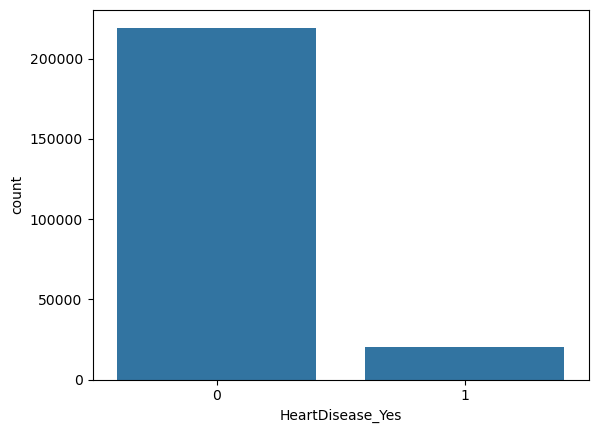

In [12]:
# HeartDisease_Yes 컬럼 클래스 분포 시각화
sns.countplot(x="HeartDisease_Yes", data=y_train)
# y_train 데이터에서 'HeartDisease_Yes' 컬럼의 각 클래스(0, 1)의 개수를 막대그래프로 시각화함
# 클래스 0은 심장 질환이 없는 경우, 클래스 1은 심장 질환이 있는 경우를 나타냄
# countplot은 각 클래스가 데이터에 얼마나 포함되어 있는지를 시각적으로 보여주며, 클래스 불균형 문제를 쉽게 확인할 수 있는 도구임
# 클래스 간 분포 차이가 클 경우 모델이 다수 클래스에 치우쳐 학습될 위험이 있으므로 언더샘플링, 오버샘플링 등 처리 전략이 필요함

plt.show()
# 위에서 정의한 그래프를 화면에 출력함
# 노트북이나 인터프리터 환경에서 시각적 결과물을 명시적으로 확인하기 위해 사용하는 출력 명령임

In [14]:
# 임시 변수명 적용

X_train_re = X_train.copy()
# 원본 학습용 독립변수(X_train)를 복사하여 X_train_re라는 새 변수로 생성함
# 이후 임시 변수명을 적용해도 원본 X_train에는 영향을 주지 않도록 하기 위한 사전 조치 수행

y_train_re = y_train.copy()
# 종속변수 y_train도 동일하게 복사하여 y_train_re 변수로 저장함
# 원본 데이터를 보존하면서 이름을 바꾸거나 샘플링을 적용할 수 있도록 사본을 활용함

X_temp_name = ['X1','X2','X3','X4','X5','X6','X7','X8','X9','X10',
            'X11','X12','X13','X14','X15','X16','X17','X18','X19','X20',
            'X21','X22','X23','X24','X25','X26','X27','X28','X29','X30',
            'X31','X32','X33','X34','X35','X36','X37']
# 독립변수 컬럼에 임시로 부여할 변수명 리스트를 생성함
# 모델 학습 시 변수명이 너무 길거나 해석에 혼란을 줄 수 있으므로 단순화된 이름을 사용하는 경우가 있음
# 전체 피처의 수(37개)에 맞게 X1~X37까지 순서대로 이름 지정함

y_temp_name = ['y1']
# 종속변수 이름을 간단히 y1로 설정함
# 이후 statsmodels와 같은 통계 분석 도구에서 수식 형태로 변수명을 지정할 때 간결한 표현이 가능하도록 준비함

X_train_re.columns = X_temp_name
# X_train_re의 컬럼명을 위에서 만든 X_temp_name 리스트로 일괄 변경함
# 피처 이름을 임시 코드화하여 분석 시 시각적으로 간결함을 유지하려는 목적 수행

y_train_re.columns = y_temp_name
# y_train_re의 컬럼명을 'y1'로 변경함
# 종속변수 이름을 간단하게 바꿈으로써 회귀 분석이나 수식 기반 모델에서 사용하기 쉽게 조정함

X_train_re.head()
# 변수명이 변경된 학습용 독립변수 테이블(X_train_re)의 상위 5개 행을 출력함
# 변경 결과를 직접 확인하고 변수명이 올바르게 적용되었는지 검토하는 단계 수행


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37
163572,-0.202977,0.0,0.0,-0.5,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
150901,1.476319,0.0,0.0,0.5,1,0,1,0,1,0,...,0,0,1,0,0,0,1,0,0,0
164527,-0.248985,15.0,10.0,-2.0,1,0,0,1,1,0,...,0,0,1,0,0,1,0,0,0,0
260971,0.805142,0.0,0.0,0.0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
262287,0.612991,5.0,0.0,0.0,0,0,0,0,1,0,...,1,0,1,0,1,0,0,0,0,0


In [ ]:
# 언더샘플링 적용

X_train_under, y_train_under = RandomUnderSampler(
    random_state=0).fit_resample(X_train_re, y_train_re)
# 다수 클래스의 샘플 수를 줄이는 언더샘플링 기법(RandomUnderSampler)을 적용하여 학습 데이터의 클래스 불균형을 해소함
# fit_resample()은 다수 클래스에서 일부 샘플을 무작위로 제거하고, 소수 클래스와 동일한 수량이 되도록 데이터셋을 재구성함
# random_state=0은 실행 시마다 동일한 결과가 재현되도록 난수 시드를 고정함
# 결과적으로 클래스별 데이터 수가 동일한 균형 잡힌 학습 데이터(X_train_under, y_train_under)로 재구성됨

print('RandomUnderSampler 적용 전 학습셋 변수/레이블 데이터 세트: '
      , X_train_re.shape, y_train_re.shape)
# 언더샘플링 전 원본 학습 데이터의 입력 변수 크기와 타겟 변수 크기를 출력함
# 샘플 수가 불균형하게 분포된 상태의 원래 크기를 기준선으로 확인함
print('RandomUnderSampler 적용 후 학습셋 변수/레이블 데이터 세트: '
      , X_train_under.shape, y_train_under.shape)
# 언더샘플링 후 재구성된 학습 데이터의 크기를 출력함
# 다수 클래스의 샘플이 줄어든 만큼 전체 행 수가 감소한 것을 확인할 수 있음

print('RandomUnderSampler 적용 전 레이블 값 분포: \n'
      , pd.Series(y_train_re['y1']).value_counts())
# 원본 학습 데이터에서 종속변수 y1의 클래스별 개수를 출력함
# 클래스 0과 1의 데이터 수 차이를 확인하여 불균형 상태를 진단함
print('RandomUnderSampler 적용 후 레이블 값 분포: \n'
      , pd.Series(y_train_under['y1']).value_counts())
# 언더샘플링을 거친 후 종속변수의 클래스별 개수를 출력함
# 클래스 0과 1의 개수가 동일하게 맞춰졌는지 확인함으로써 샘플링 적용 결과를 검증함


RandomUnderSampler 적용 전 학습셋 변수/레이블 데이터 세트:  (239846, 37) (239846, 1)
RandomUnderSampler 적용 후 학습셋 변수/레이블 데이터 세트:  (41036, 37) (41036, 1)
RandomUnderSampler 적용 전 레이블 값 분포: 
 0    219328
1     20518
Name: y1, dtype: int64
RandomUnderSampler 적용 후 레이블 값 분포: 
 0    20518
1    20518
Name: y1, dtype: int64


In [ ]:
# 컬럼명 복구
X_train_under.columns = list(X_train)
# list(X_train)은 실제로는 list(X_train.columns)과 동일하게 동작
# 언더샘플링 처리된 학습 입력 데이터(X_train_under)의 컬럼명을 원래 X_train의 컬럼명 리스트로 복구함
# 임시 변수명(X1, X2, ...) 대신 원래의 실제 피처명(BMI, AgeCategory_OldAdult 등)을 적용하여 해석 가능성을 확보함
# 이후 회귀 계수 해석, 회귀 결과 표 출력 시 각 변수의 의미를 명확하게 파악할 수 있도록 설정함

y_train_under.columns = list(y_train)
# 타겟 데이터(y_train_under)의 컬럼명도 원래 y_train 컬럼명으로 복구함
# 주로 ['HeartDisease_Yes'] 형태로 설정되어 있으며, 분석 결과 해석 시 예측 대상이 무엇인지 명확하게 하기 위함임

X_train_under.head()

,BMI,PhysicalHealth,MentalHealth,SleepTime,Smoking_Yes,AlcoholDrinking_Yes,Stroke_Yes,DiffWalking_Yes,Sex_Male,AgeCategory_25-29,...,Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_Yes,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes
69819,-0.572395,0.0,1.666667,0.5,0,0,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0
248332,2.365359,6.0,0.333333,-0.5,0,0,0,0,0,0,...,1,0,1,1,0,0,0,0,0,0
31381,-0.964817,0.0,2.666667,0.5,0,0,0,0,1,0,...,0,0,1,0,0,0,1,1,0,0
152264,-1.246279,0.0,0.000000,-0.5,1,0,0,1,1,0,...,0,0,1,0,1,0,0,1,0,0
90674,0.668471,15.0,0.000000,0.5,1,0,0,0,1,0,...,1,0,1,1,0,0,0,0,0,0


In [18]:
# 학습셋 모델 학습

model = LogisticRegression()
# 로지스틱 회귀(Logistic Regression) 모델 객체를 생성함
# 이진 분류 문제에 주로 사용되는 선형 모델로, 시그모이드 함수를 통해 입력값을 0과 1 사이의 확률로 변환함
# 하이퍼파라미터는 기본값 사용 (패널티는 L2, 정규화 강도는 C=1.0 등)

model.fit(X_train_under, y_train_under)
# 언더샘플링된 학습용 데이터(X_train_under, y_train_under)를 사용하여 로지스틱 회귀 모델을 훈련시킴
# 각 입력 변수에 대한 회귀 계수를 최적화하여 심장질환 유무를 예측하는 분류 모델을 구성함
# 내부적으로는 최대우도 추정(MLE)을 통해 가중치 계수를 학습함

print('학습셋 모델 정확도:', model.score(X_train_under, y_train_under))
# 훈련된 모델이 학습 데이터에서 얼마나 정확히 예측했는지를 정확도(Accuracy) 기준으로 출력함
# 정확도는 전체 샘플 중에서 올바르게 예측한 샘플의 비율을 의미함
# 학습셋 기준이므로 과적합 여부를 판단하려면 반드시 테스트셋 성능도 함께 확인해야 함


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


학습셋 모델 정확도: 0.7646213081196997


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# 테스트셋 모델 적합

print('테스트셋 모델 정확도:', model.score(X_test, y_test))
# 학습된 로지스틱 회귀 모델을 테스트셋에 적용하여 예측 정확도를 계산하고 출력함
# score() 함수는 내부적으로 정확도(Accuracy) 지표를 계산함 → 전체 테스트 데이터 중 정답을 맞힌 비율을 의미함
# 학습에 사용되지 않은 데이터를 기반으로 모델의 일반화 성능을 평가하는 단계임
# 테스트셋 정확도와 학습셋 정확도를 비교함으로써 과적합 여부(예: 학습은 잘되었지만 테스트 성능은 낮은 경우)를 판단

테스트셋 모델 정확도: 0.7502407784962913


In [ ]:
# 계수값(가중치) 확인

print(model.coef_)
# 학습된 로지스틱 회귀 모델에서 각 독립변수에 해당하는 회귀 계수(coefficient)를 출력함
# 각 계수는 해당 독립변수가 종속변수(심장질환 유무)에 미치는 영향력을 수치적으로 나타냄
# 계수가 양수이면 해당 변수가 증가할수록 심장질환이 발생할 확률(odds ratio)이 증가함을 의미함
# 계수가 음수이면 해당 변수가 증가할수록 심장질환 발생 확률이 감소함을 의미함
# 계수의 절댓값이 클수록 영향력이 크며, 단위는 로그 오즈(log-odds) 단위임
# 이 값들은 변수명을 함께 출력하거나 시각화해야 해석이 용이함 (→ 다음과 같이 확인 가능함)

# 예시: 변수명과 함께 계수 확인하기
import pandas as pd
pd.Series(model.coef_[0], index=X_train_under.columns).sort_values(ascending=False)
# 각 변수명을 인덱스로 하여 계수를 시리즈 형태로 정리함
# 계수가 큰 순서 또는 작은 순서대로 정렬하여 영향력 있는 변수 식별 가능함


[[ 7.89773362e-02  1.19355147e-02  2.94670218e-02 -5.42654590e-02
   4.05879319e-01 -2.46923336e-01  1.28168362e+00  2.00027030e-01
   7.60704584e-01 -5.69813494e-02  3.96610931e-01  4.16243273e-01
   7.90247788e-01  1.07691114e+00  1.52952908e+00  1.76685849e+00
   2.04629303e+00  2.33314918e+00  2.68573068e+00  2.84198498e+00
   3.20321960e+00 -5.28827307e-01 -2.43799268e-01 -1.83514048e-01
  -9.65987166e-02 -6.01784437e-02  2.81239083e-01  4.80550126e-01
   4.37555504e-01 -2.22174371e-03  1.50009879e+00  1.02836487e+00
   1.81152423e+00  4.45485419e-01  2.93899802e-01  6.17308530e-01
   1.41808368e-01]]


In [22]:
# 다른 로지스틱 모델로 학습

model2 = sm.Logit(y_train_under, X_train_under)
# statsmodels의 Logit 클래스를 사용하여 로지스틱 회귀(Logistic Regression) 모델 객체를 생성함
# Logit은 이항 로지스틱 회귀(Binomial Logistic Regression)를 수식 기반으로 구성할 수 있는 통계 모델임
# 입력값으로는 종속변수(y_train_under)와 독립변수(X_train_under)를 지정하며, 데이터는 모두 수치형이어야 함
# 이 모델은 확률적 추정을 위한 최대우도법(Maximum Likelihood Estimation, MLE)을 사용하여 계수를 추정함

results = model2.fit(method = "newton") 
# 로지스틱 회귀 모델을 뉴턴-랩슨(Newton-Raphson) 방법을 이용하여 학습시킴
# Newton 방법은 수치 최적화 알고리즘 중 하나로, 로지스틱 회귀 계수를 최대우도 방식으로 반복 추정함
# 결과로 회귀 계수, 표준 오차, 유의성 검정 결과 등 다양한 통계 정보를 담은 results 객체가 생성됨

results.summary()
# 학습된 로지스틱 회귀 모델에 대한 전체 통계 분석 결과 요약 표를 출력함
# 출력 내용에는 다음과 같은 항목이 포함됨:

# - coef: 회귀 계수 (각 변수의 영향력, 로그 오즈 단위)
# - std err: 계수의 표준 오차
# - z: z-통계량 (계수 / 표준오차)
# - P>|z|: 각 계수에 대한 유의확률 (p-value, 0.05 미만이면 통계적으로 유의함)
# - [0.025, 0.975]: 95% 신뢰구간
# - Log-Likelihood, AIC, BIC: 모델의 적합도 및 복잡도를 평가하는 지표

# 이 summary는 단순 정확도 외에도 변수의 유의성, 모델의 적합성, 다중공선성 징후 등을 진단할 수 있는 강력한 해석 도구임

Optimization terminated successfully.
         Current function value: inf
         Iterations 7


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       HeartDisease_Yes   No. Observations:                41036
Model:                          Logit   Df Residuals:                    40999
Method:                           MLE   Df Model:                           36
Date:                Wed, 07 May 2025   Pseudo R-squ.:                     inf
Time:                        12:38:04   Log-Likelihood:                   -inf
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                     1.000
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
BMI                                  0.0918      0.015      6.056      0.000       0.062       0.121
PhysicalHealth                       0.0114      0.003      3.367      0.001       0.005       0.018
MentalHealth                         0.0170      0.005      3.478      0.001       0.007       0.027
SleepTime                           -0.0733      0.016     -4.619      0.000      -0.104      -0.042
Smoking_Yes                          0.3696      0.025     14.807      0.000       0.321       0.419
AlcoholDrinking_Yes                 -0.2732      0.053     -5.107      0.000      -0.378      -0.168
Stroke_Yes                           1.2616      0.054     23.555      0.000       1.157       1.367
DiffWalking_Yes                      0.1708      0.035      4.907      0.000       0.103       0.239
Sex_Male                             0.6680      0.025     26.580      0.000       0.619       0.717
AgeCategory_25-29                   -1.4044      0.127    -11.088      0.000      -1.653      -1.156
AgeCategory_30-34                   -0.9200      0.103     -8.905      0.000      -1.122      -0.717
AgeCategory_35-39                   -0.9326      0.097     -9.634      0.000      -1.122      -0.743
AgeCategory_40-44                   -0.5486      0.089     -6.190      0.000      -0.722      -0.375
AgeCategory_45-49                   -0.2661      0.082     -3.244      0.001      -0.427      -0.105
AgeCategory_50-54                    0.1993      0.076      2.636      0.008       0.051       0.348
AgeCategory_55-59                    0.4354      0.072      6.049      0.000       0.294       0.576
AgeCategory_60-64                    0.7295      0.070     10.414      0.000       0.592       0.867
AgeCategory_65-69                    1.0211      0.070     14.680      0.000       0.885       1.157
AgeCategory_70-74                    1.3695      0.070     19.549      0.000       1.232       1.507
AgeCategory_75-79                    1.5302      0.073     20.958      0.000       1.387       1.673
AgeCategory_80 or older              1.8668      0.072     25.936      0.000       1.726       2.008
Race_Asian                          -2.6688      0.120    -22.307      0.000      -2.903      -2.434
Race_Black                          -2.3371      0.081    -28.721      0.000      -2.497      -2.178
Race_Hispanic                       -2.3334      0.080    -29.136      0.000      -2.490      -2.176
Race_Other                          -2.2070      0.093    -23.681      0.000      -2.390      -2.024
Race_White                          -2.1554      0.069    -31.379      0.000      -2.290      -2.021
Diabetic_No, borderline diabetes     0.2903      0.078      3.734      0.000       0.138       0.443
Diabetic_Yes                         0.4801      0.032     14.907      0.000       0.417       0.543
Diabetic_Yes (during pregnancy)      0.2256      0.164      1.376      0.169      -0.096       0.547
PhysicalA

In [23]:
# 오즈비 확인

np.exp(results.params)
# statsmodels로 학습한 로지스틱 회귀 모델의 회귀 계수(results.params)를 지수 함수(np.exp)로 변환하여 오즈비(Odds Ratio)를 계산함
# 오즈비는 해당 독립변수가 한 단위 증가할 때, 결과 변수(심장질환 발생)의 odds가 몇 배나 증가 또는 감소하는지를 수치적으로 나타내는 지표임

# 해석 예시:
# - 오즈비가 1보다 크면 → 해당 변수의 값이 증가할수록 심장질환 발생 가능성이 증가함
# - 오즈비가 1보다 작으면 → 해당 변수의 값이 증가할수록 심장질환 발생 가능성이 감소함
# - 오즈비가 정확히 1이면 → 해당 변수는 심장질환 발생에 영향을 미치지 않는다는 의미임

# log(오즈비) = 회귀 계수 → 오즈비 = exp(회귀 계수)
# 이 변환을 통해 로그 오즈 단위의 계수를 실질적 해석이 가능한 배율(odds ratio)로 변환할 수 있음


BMI                                 1.096091
PhysicalHealth                      1.011469
MentalHealth                        1.017101
SleepTime                           0.929300
Smoking_Yes                         1.447148
AlcoholDrinking_Yes                 0.760970
Stroke_Yes                          3.530911
DiffWalking_Yes                     1.186292
Sex_Male                            1.950422
AgeCategory_25-29                   0.245524
AgeCategory_30-34                   0.398530
AgeCategory_35-39                   0.393534
AgeCategory_40-44                   0.577770
AgeCategory_45-49                   0.766331
AgeCategory_50-54                   1.220555
AgeCategory_55-59                   1.545532
AgeCategory_60-64                   2.074125
AgeCategory_65-69                   2.776307
AgeCategory_70-74                   3.933446
AgeCategory_75-79                   4.619038
AgeCategory_80 or older             6.467417
Race_Asian                          0.069335
Race_Black

### 오즈비 해석 표 (일부)

| 변수명 | 오즈비 | 해석 |
| --- | --- | --- |
| **BMI** | 1.096 | BMI가 1 단위 증가할 때 심장질환 발생 가능성이 약 **9.6% 증가함** |
| **PhysicalHealth** | 1.011 | 신체 건강 문제 일수가 하루 증가할 때 **1.1% 증가함** → 영향 미미 |
| **MentalHealth** | 1.017 | 정신 건강 문제 일수가 하루 증가할 때 **1.7% 증가함** → 영향 미미 |
| **SleepTime** | 0.929 | 수면 시간이 1시간 증가할 때 **심장질환 발생 가능성이 약 7.1% 감소함** |
| **Smoking_Yes** | 1.447 | 흡연자는 비흡연자보다 심장질환 발생 가능성이 **약 45% 높음** |
| **AlcoholDrinking_Yes** | 0.761 | 과음하는 사람은 그렇지 않은 사람보다 심장질환 발생 가능성이 **약 24% 낮음** *(※ 역설적 해석 주의 필요)* |
| **Stroke_Yes** | 3.531 | 뇌졸중 경험자는 그렇지 않은 사람보다 심장질환 발생 가능성이 **약 3.5배 높음** |
| **Sex_Male** | 1.950 | 남성은 여성보다 심장질환 발생 가능성이 **약 1.95배 높음** |
| **AgeCategory_60-64** | 2.074 | 기준 연령군 대비 60–64세는 심장질환 발생 가능성이 **2배 이상 높음** |
| **AgeCategory_80 or older** | 6.467 | 기준 연령군 대비 80세 이상은 심장질환 발생 가능성이 **약 6.5배 높음** |
| **Race_Asian** | 0.069 | 아시아인은 기준 인종군보다 심장질환 발생 가능성이 **93% 이상 낮음** |
| **KidneyDisease_Yes** | 1.851 | 신장질환이 있는 사람은 없는 사람보다 심장질환 가능성이 **약 1.85배 높음** |